In [1]:
import matplotlib.pyplot as plt
import dask.array as da
import dask_image.ndfilters
from skimage.measure import label
import tifffile
import skimage as ski
import pandas as pd
import os
import numpy as np
from scipy import ndimage as ndi
import segment_functions as fun
import extract_phenotype

import importlib
import myutils
importlib.reload(fun)
importlib.reload(extract_phenotype)
importlib.reload(myutils)

/Users/hannahbolen/miniforge3/envs/slide_env/lib/python3.11/site-packages/microfilm/__init__.py:1: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import get_distribution, DistributionNotFound


<module 'myutils' from '/Users/hannahbolen/Desktop/image_analysis/whole_slide/myutils.py'>

In [10]:
# read in image
root = "/Users/hannahbolen/Desktop/image_analysis/"
img_name = "o8n_day3.vsi - 20x_FITC, Cy5_01.ome.tif"
img_path = os.path.join(root, img_name)
img = da.from_array(tifffile.imread(img_path))

In [11]:
# # read in image
# assign channels
FITC = 0
cy5 = 1
# constants -- display
ds = 10
H, W = img[FITC].shape
# make tile from center of image
y0 = H//2 - 5120 # underlying "tile" size of 512, make tile excerpt multiple of 512
x0 = W//2 - 5120

## tile parameters for day 24
# x0 = 10700
# y0 = 29500 # underlying "tile" size of 512, make tile excerpt multiple of 512
# # make tile from center of image -- tile for day24
# nucleiTile = img[FITC,y0:y0+1400, x0:x0+1400]
# cy5Tile = img[cy5, y0:y0+1400, x0:x0+1400]
# imgTile = img[:,y0:y0+1400, x0:x0+1400]

nucleiTile = img[FITC,y0:y0+5120, x0:x0+5120]
cy5Tile = img[cy5, y0:y0+5120, x0:x0+5120]
imgTile = img[:,y0:y0+5120, x0:x0+5120]
# make even smaller tile
nucleiZoom = nucleiTile[1000:3000, 2000:4000]
cy5Zoom = cy5Tile[1000:3000, 2000:4000]
imgZoom = imgTile[:,1000:3000, 2000:4000]

In [5]:
# constants -- processing
umPerPx = 0.325
nucleiThreshold = 50
nucleiMin = 150/umPerPx**2
nucleiMax = 12000/umPerPx**2
nucleiMean = 300/umPerPx**2
smooth=3
cy5_range = (256, 6000)
foci_radius = 5
foci_threshold = 50
# function to visualize
def visualize(base,base_title = "nuclei", clrs=[],**images):
    plt.figure(figsize = (18,18))
    plt.subplot(2, 3, 1)
    plt.axis('off')
    plt.imshow(base, cmap = "gray")
    plt.title(base_title)
    if len(clrs) == len(images):
        for i, img in enumerate(images.keys(), start=2):
            plt.subplot(2,3,i)
            plt.title(img)
            plt.imshow(images[img], cmap = clrs[i-2])
            plt.axis('off')
            plt.tight_layout()
    elif len(clrs) == 1:
        for i, img in enumerate(images.keys(), start=2):
            plt.subplot(2,3,i)
            plt.title(img)
            plt.imshow(images[img], cmap = clrs[0])
            plt.axis('off')
            plt.tight_layout()
    elif len(clrs) == 0:
        for i, img in enumerate(images.keys(), start=2):
            plt.subplot(2,3,i)
            plt.title(img)
            plt.imshow(images[img])
            plt.axis('off')
            plt.tight_layout()
    else:
        return("Error - incompatible cmap provided")
    plt.show()

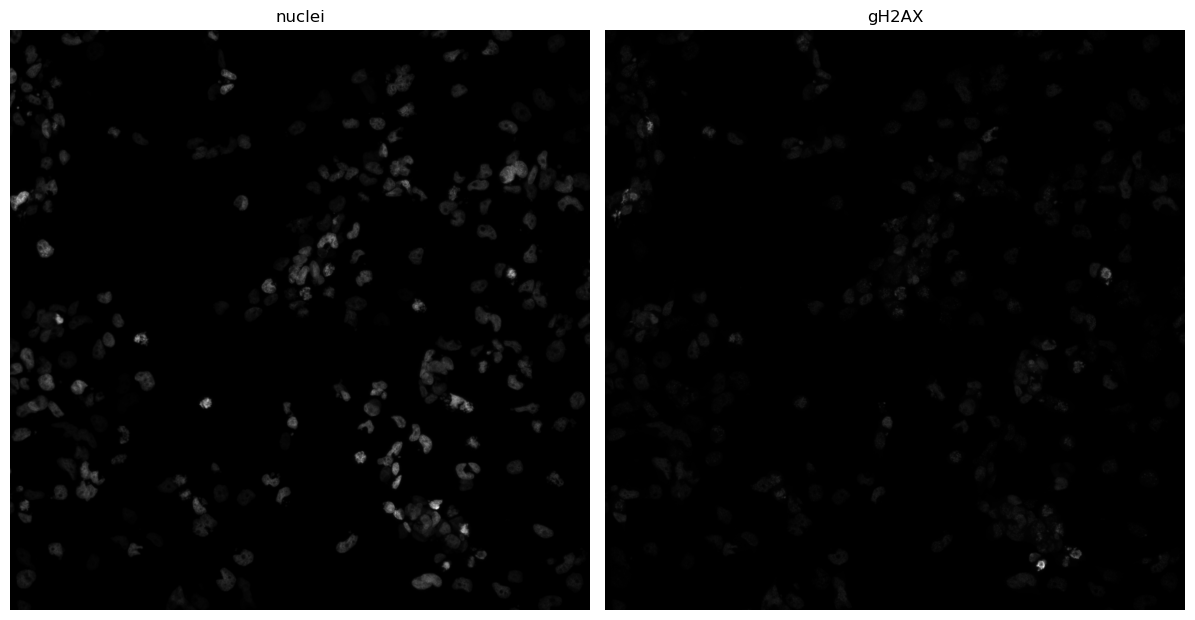

In [12]:
visualize(nucleiZoom, clrs = ["gray"], **{"gH2AX": imgZoom[cy5]})

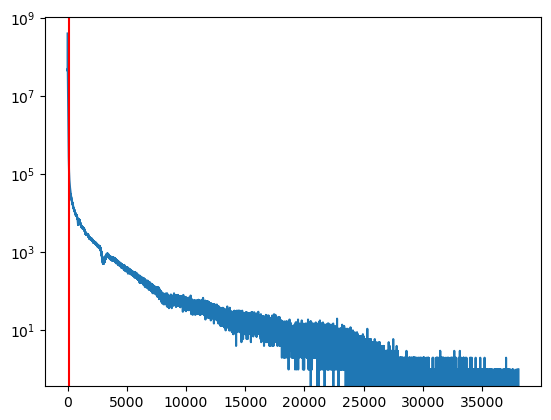

In [25]:
fig, ax = plt.subplots()
hist, hist_centers = ski.exposure.histogram(img[FITC])
ax.plot(hist_centers, hist)
ax.axvline(100, color = 'r')
plt.yscale('log')
plt.show()

In [13]:
# timer
importlib.reload(fun)
fun.OPS_PROFILE = True
fun.OPS_PROFILE_VERBOSE = True
fun.ops_timing_reset()
# nuclei segmentation arguments
nucleiArgs = dict(threshold=lambda x: nucleiThreshold, 
            area_min=nucleiMin, area_max=nucleiMax,
            smooth=smooth)
# segment nuclei
nuclei = fun.find_nuclei(nucleiTile, **nucleiArgs)
fun.ops_timing_summary()

[ops_timer] simple_binary: 0.536s
[ops_timer] label: 0.042s
[ops_timer] filter_by_region_initial: 0.298s
[ops_timer] fill_holes: 0.309s
[ops_timer] label_hole_diff: 0.044s
[ops_timer] filter_by_region_holes: 0.260s
[ops_timer] apply_hole_fill: 0.001s
[ops_timer] watershed: 2.016s
[ops_timer] filter_by_region_final: 0.249s


['watershed                   2.016s   53.7%\n',
 'simple_binary               0.536s   14.3%\n',
 'fill_holes                  0.309s    8.2%\n',
 'filter_by_region_initial    0.298s    7.9%\n',
 'filter_by_region_holes      0.260s    6.9%\n',
 'filter_by_region_final      0.249s    6.6%\n',
 'label_hole_diff             0.044s    1.2%\n',
 'label                       0.042s    1.1%\n',
 'apply_hole_fill             0.001s    0.0%\n',
 'total                       3.754s  100.0%\n']

In [14]:
extract_phenotype.count_labels(nuclei)

0

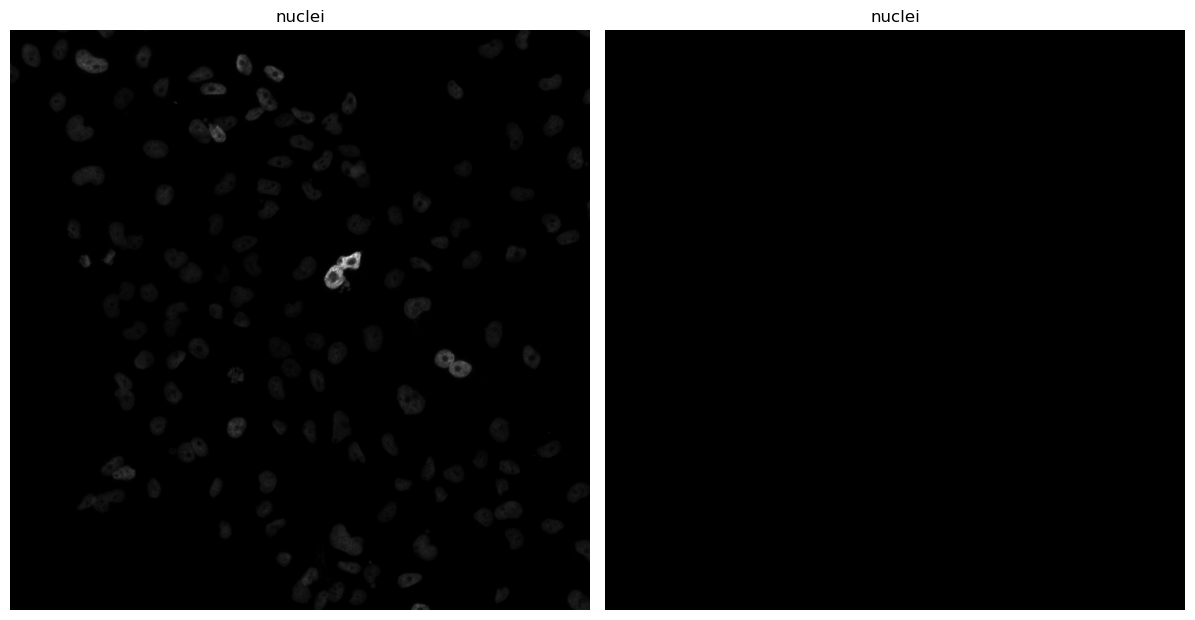

In [32]:
visualize(imgTile[FITC], **{"nuclei": ski.color.label2rgb(nuclei)})

In [15]:
nuclei.max

<function ndarray.max>

In [19]:
importlib.reload(extract_phenotype)
importlib.reload(fun)

<module 'segment_functions' from '/Users/hannahbolen/Desktop/image_analysis/whole_slide/segment_functions.py'>

In [7]:
print("Extracting phenotype features:")

# Extract features using CellProfiler emulator
phenotype_cp, foci = extract_phenotype.extract_phenotype_cp_multichannel(
    imgZoom,
    nuclei=nuclei,
    cells=None,
    wildcards=None,
    cytoplasms=None,
    foci_channel=cy5,
    channel_names=["FITC", "cy5"]
)

phenotype_cp.to_csv("/Users/hannahbolen/Desktop/image_analysis/imgZoom_featureTable")
phenotype_cp

Extracting phenotype features:


,label,nucleus_i,nucleus_j,nucleus_bounds_0,nucleus_bounds_1,nucleus_bounds_2,nucleus_bounds_3,nucleus_area,nucleus_cy5_foci_count,nucleus_cy5_foci_area,nucleus_number_neighbors_1,nucleus_percent_touching_1,nucleus_first_neighbor_distance,nucleus_second_neighbor_distance,nucleus_angle_between_neighbors
0,1,151.178099,270.471995,129,248,170,295,1589.0,1,76,1,0.220930,38.814945,207.034042,5.369967
1,2,189.980928,269.502225,170,246,219,288,1573.0,1,62,1,0.213483,38.814945,168.428626,173.394221
2,3,357.723245,284.691600,333,261,388,305,1738.0,0,0,1,0.181395,46.388532,168.428626,104.797672
3,4,365.478198,330.427326,341,304,392,360,2064.0,0,0,1,0.179724,46.388532,185.771794,61.231654
4,5,438.527190,1134.298590,409,1110,474,1162,1986.0,2,162,0,0.000000,167.028772,553.287385,25.753494
5,6,459.878306,1813.336272,425,1773,497,1858,4651.0,0,0,0,0.000000,295.261688,603.525055,47.622909
6,7,561.663696,171.306684,528,125,593,219,3815.0,6,1096,0,0.000000,233.340623,252.602708,9.971777
7,8,605.094749,1121.894597,570,1096,650,1146,2628.0,1,51,0,0.000000,167.028772,409.334265,144.034107
8,9,709.159961,1971.570658,680,1944,736,1993,2038.0,1,49,0,0.000000,295.261688,459.574551,104.043345
9,10,953.334465,1337.030926,893,1262,1010,1405,11188.0,1,184,0,0.000000,283.252013,309.896097,108.160100


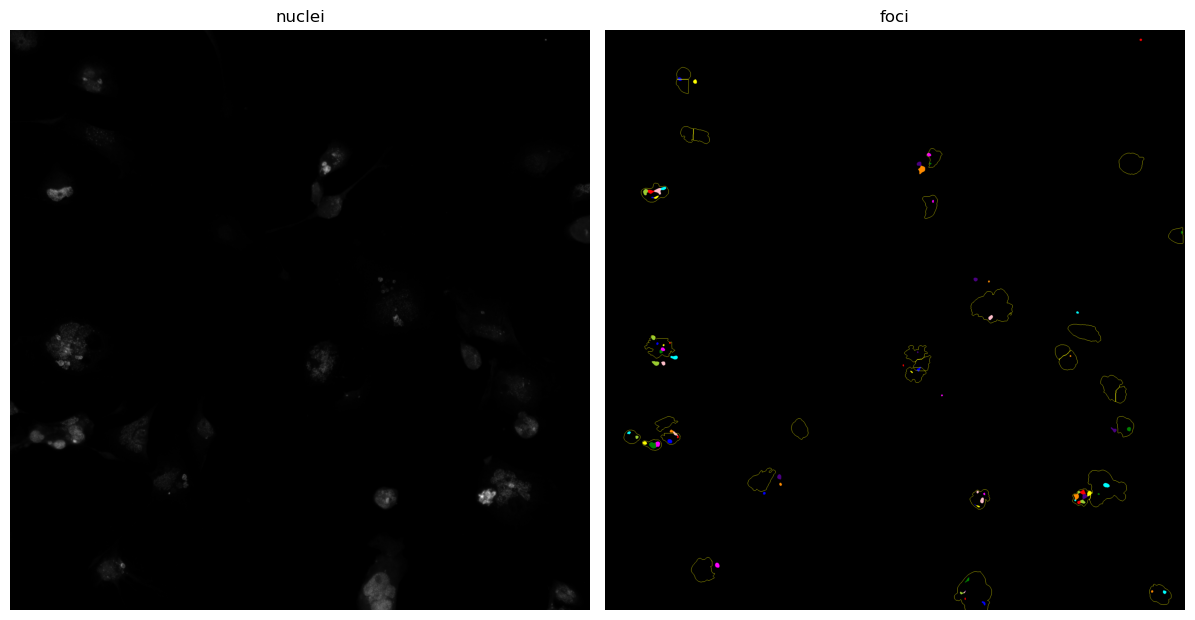

In [9]:
visualize(imgZoom[cy5], **{"foci":ski.segmentation.mark_boundaries(ski.color.label2rgb(foci), nuclei)})

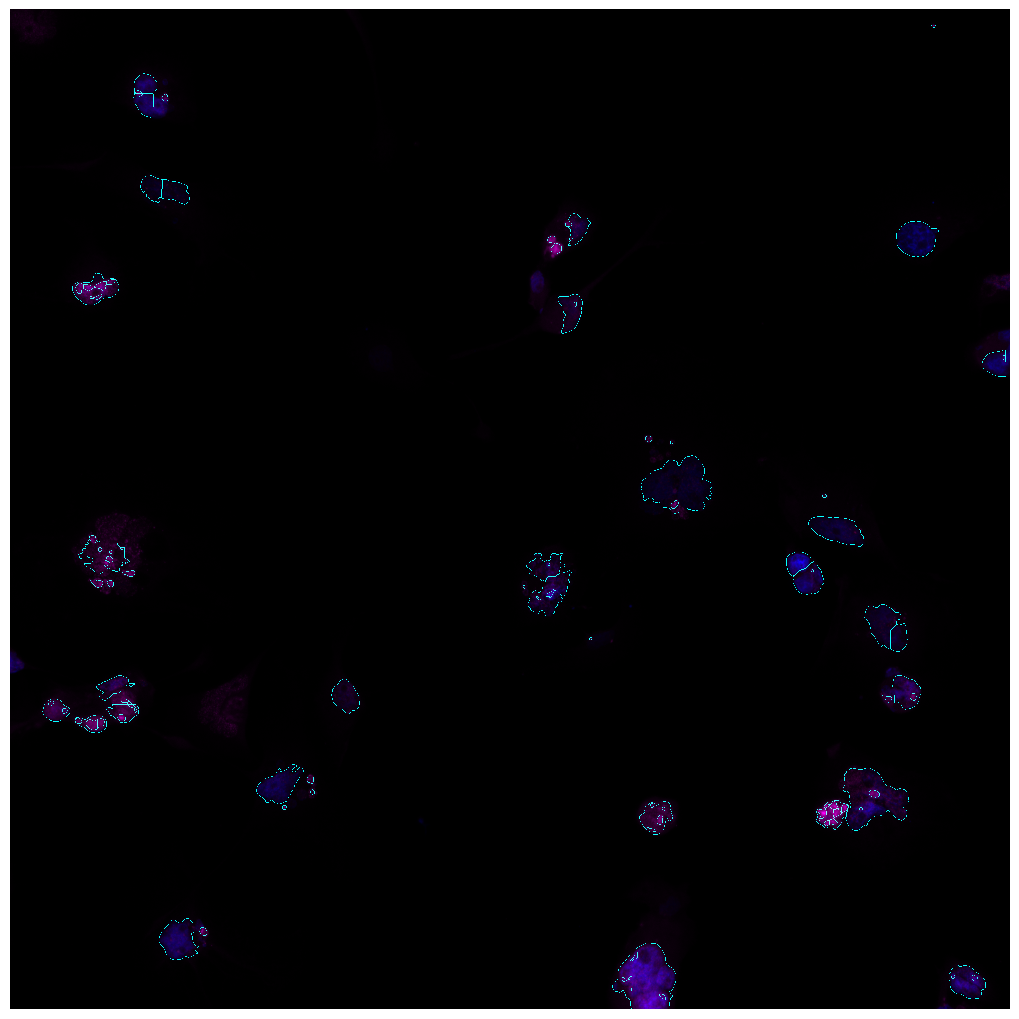

In [ ]:
 "outlines":ski.segmentation.mark_boundaries(ski.exposure.rescale_intensity(cy5Zoom,in_range = cy5_range), foci)


In [11]:
foci_test = extract_phenotype.find_foci(imgZoom[cy5,:,:])